<a href="https://colab.research.google.com/github/dee431/Student-Lifestyle-and-Stress-Prediction-/blob/main/Student_Lifestyle_and_Stress_Prediction_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Cell 1: Library Imports and Data loading**

In [18]:
# ==========================================
# BLOCK 1: IMPORTS AND DATA LOADING
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, accuracy_score

# Upload the file manually to Colab or load it if already in workspace
# If uploading via code, uncomment the next two lines:
# from google.colab import files
# uploaded = files.upload()

file_path = 'student_lifestyle_and_stress_dataset_updated.csv'
try:
    df = pd.read_csv('/content/student_lifestyle_and_stress_dataset_updated.csv')
    print("Dataset loaded successfully!")
    print(f"Dataset Shape: {df.shape}")
    display(df.head())
except FileNotFoundError:
    print(f"Error: Please ensure '{'/content/student_lifestyle_and_stress_dataset_updated.csv'}' is uploaded to your current Google Colab directory.")

Dataset loaded successfully!
Dataset Shape: (25500, 11)


,Serial_No,Student_Name,Student_Type,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level
0,1,Aarav Sharma,school,6.868702,1.711722,3.176942,NaN,8.0,7.0,2.0,1
1,2,Vivaan Sharma,school,8.519088,3.251084,3.880787,93.978465,6.0,4.0,3.0,1
2,3,Aditya Sharma,college,4.498770,6.306885,2.936172,64.421253,7.0,1.0,12.0,1
3,4,Arjun Sharma,school,8.591223,2.384922,5.222832,81.868960,2.0,7.0,7.0,0
4,5,Rohan Sharma,college,5.329293,9.345179,7.815869,85.847982,5.0,6.0,10.0,1


**Cell 2: Data Preprocessing and Cleaning**

In [19]:
# ==========================================
# BLOCK 2: DATA PREPROCESSING
# ==========================================

# 1. Handle Missing Values
# Identify numerical columns for imputation
num_cols = ['Sleep_Hours', 'Study_Hours', 'Social_Media_Hours', 'Attendance', 'Exam_Pressure', 'Family_Support', 'Month']
imputer = SimpleImputer(strategy='median')
df[num_cols] = imputer.fit_transform(df[num_cols])

# Handle target missing values if any
df['Stress_Level'] = df['Stress_Level'].fillna(df['Stress_Level'].mode()[0]).astype(int)

# 2. Encode Categorical Variables
le_type = LabelEncoder()
df['Student_Type'] = le_type.fit_transform(df['Student_Type'].astype(str))

print("Data preprocessing complete. Missing values handled with median imputation.")
display(df.info())

Data preprocessing complete. Missing values handled with median imputation.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25500 entries, 0 to 25499
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Serial_No           25500 non-null  int64  
 1   Student_Name        25500 non-null  object 
 2   Student_Type        25500 non-null  int64  
 3   Sleep_Hours         25500 non-null  float64
 4   Study_Hours         25500 non-null  float64
 5   Social_Media_Hours  25500 non-null  float64
 6   Attendance          25500 non-null  float64
 7   Exam_Pressure       25500 non-null  float64
 8   Family_Support      25500 non-null  float64
 9   Month               25500 non-null  float64
 10  Stress_Level        25500 non-null  int64  
dtypes: float64(7), int64(3), object(1)
memory usage: 2.1+ MB


None

**Cell 3: Model Training (Predictive AI)**

In [20]:
# ==========================================
# BLOCK 3: AI MODEL TRAINING
# ==========================================

# Define features and target variable
features = ['Student_Type', 'Sleep_Hours', 'Study_Hours', 'Social_Media_Hours', 'Attendance', 'Exam_Pressure', 'Family_Support']
X = df[features]
y = df['Stress_Level']

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and train Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate model performance
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Training Complete! Baseline Accuracy: {accuracy:.2%}\n")
print("Classification Report:\n", classification_report(y_test, y_pred))

Model Training Complete! Baseline Accuracy: 80.75%

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.90      0.87      3571
           1       0.72      0.58      0.64      1529

    accuracy                           0.81      5100
   macro avg       0.78      0.74      0.76      5100
weighted avg       0.80      0.81      0.80      5100



**Cell 4: Individual Student Profile Lookup & Dynamic Visualizations**

📊 PROFILE ANALYSIS FOR: Aman Sharma (ID: 8)
🏫 Student Type: college
🎯 Actual Stress Level: 0 | 🤖 AI Predicted Stress Level: 0


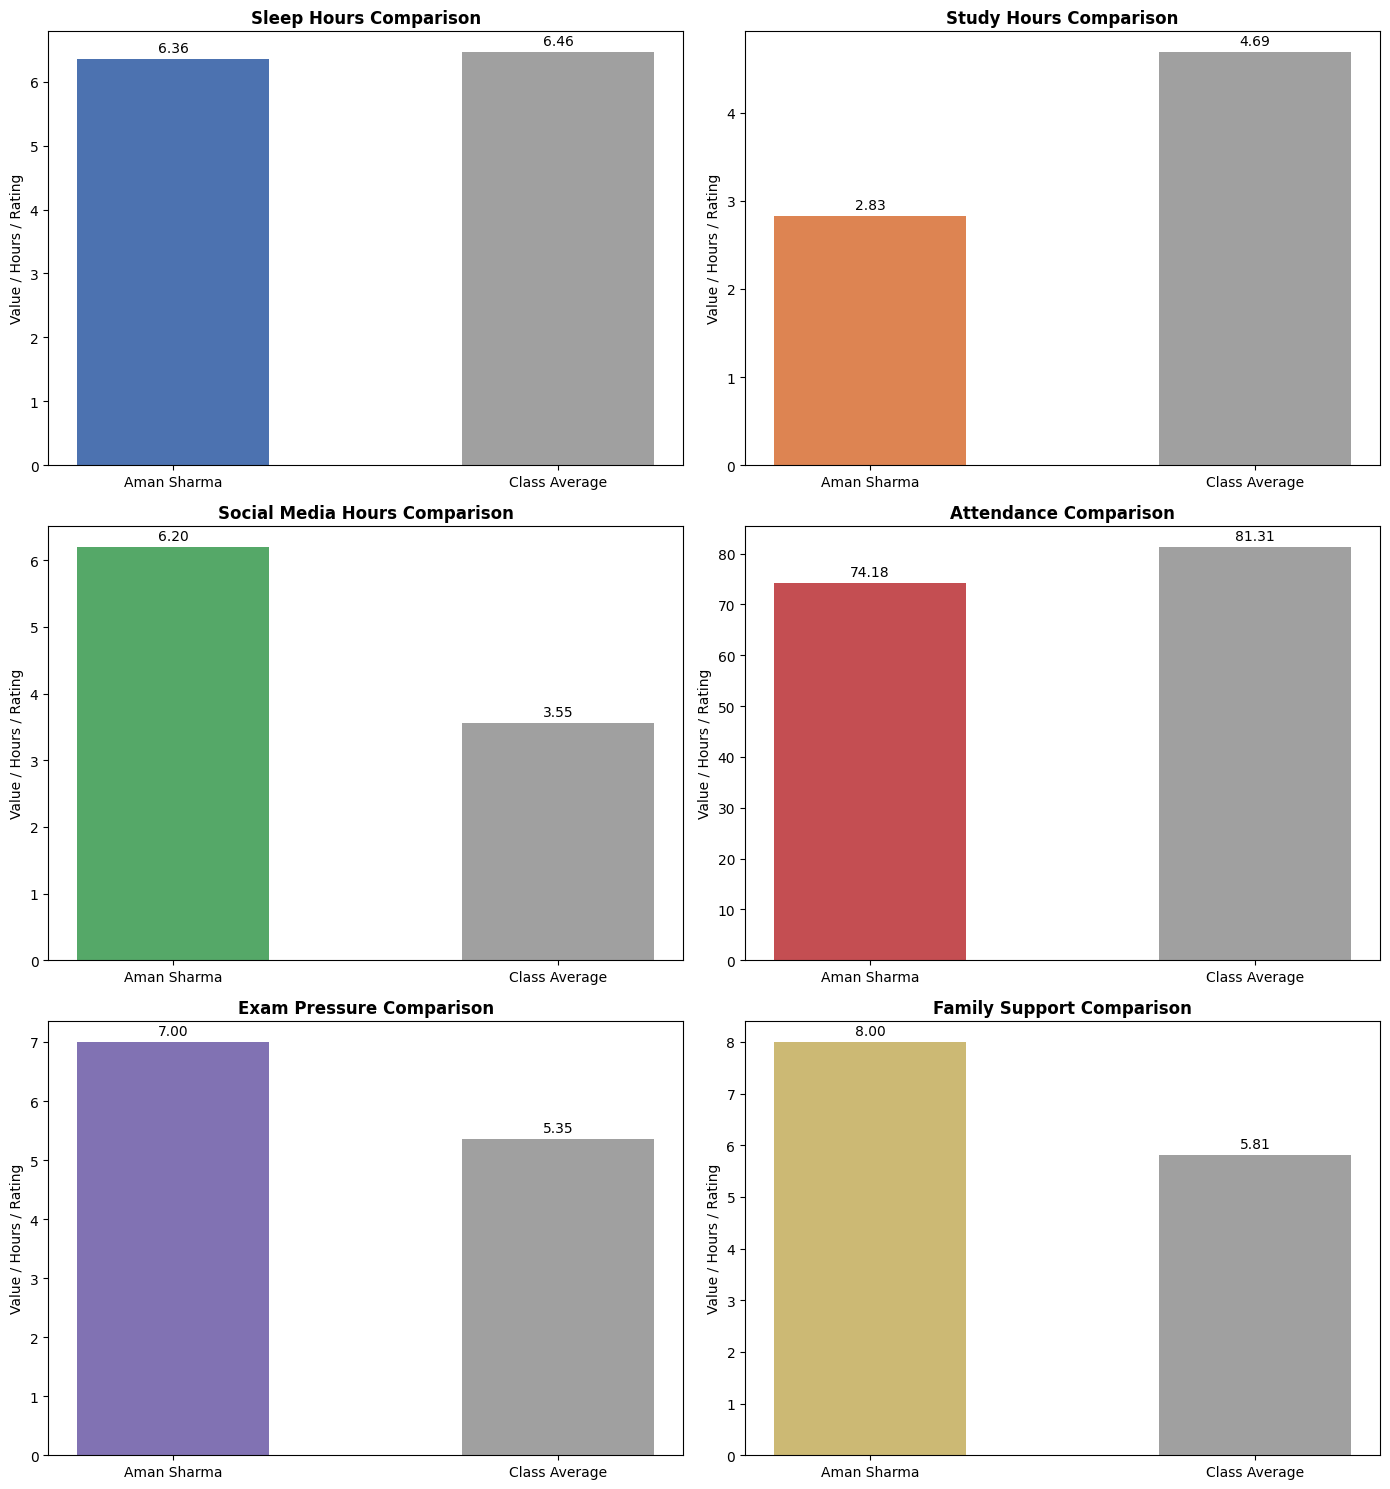

In [17]:
# ==========================================
# BLOCK 4: STUDENT VISUALIZATION & PREDICTION TOOL
# ==========================================

def analyze_student_by_id(serial_number):
    # Search for the student
    student_row = df[df['Serial_No'] == serial_number]

    if student_row.empty:
        print(f"🚨 Student with Serial Number {serial_number} not found. Please try a different ID.")
        return

    student = student_row.iloc[0]

    # Extract lifestyle metrics
    student_features = pd.DataFrame([student[features]])
    predicted_stress = model.predict(student_features)[0]
    actual_stress = int(student['Stress_Level'])

    # Print student info
    print("=" * 50)
    print(f"📊 PROFILE ANALYSIS FOR: {student['Student_Name']} (ID: {serial_number})")
    print(f"🏫 Student Type: {le_type.inverse_transform([int(student['Student_Type'])])[0]}")
    print(f"🎯 Actual Stress Level: {actual_stress} | 🤖 AI Predicted Stress Level: {predicted_stress}")
    print("=" * 50)

    # Calculate population averages for comparison
    avg_metrics = df[features].mean()

    # Define metrics to plot
    plot_metrics = ['Sleep_Hours', 'Study_Hours', 'Social_Media_Hours', 'Attendance', 'Exam_Pressure', 'Family_Support']
    student_vals = [student[m] for m in plot_metrics]
    avg_vals = [avg_metrics[m] for m in plot_metrics]

    # Generate Subplots for all required metrics
    fig, axes = plt.subplots(3, 2, figsize=(14, 15))
    axes = axes.flatten()

    colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3', '#CCB974']

    for i, metric in enumerate(plot_metrics):
        ax = axes[i]
        bars = ax.bar([f"{student['Student_Name']}", 'Class Average'], [student_vals[i], avg_vals[i]], color=[colors[i], '#A0A0A0'], width=0.5)
        ax.set_title(f"{metric.replace('_', ' ')} Comparison", fontsize=12, fontweight='bold')
        ax.set_ylabel('Value / Hours / Rating')

        # Add labels on top of bars
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.2f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

# --- RUN THE LOOKUP HERE ---
# Change the number below to look up any valid Serial_No from your dataset
lookup_id = 8
analyze_student_by_id(lookup_id)